--- SU(2) NUMERICAL HESSIAN SCAN (L=2^4) ---
Matrix Size: 192x192
------------------------------------------------------------
Beta       | Lambda_min           | Status
0.5000     | 0.5000               | OK
0.8889     | 0.8889               | OK
1.2778     | 1.2778               | OK
1.6667     | 1.6667               | OK
2.0556     | 2.0556               | OK
2.4444     | 2.4444               | OK
2.8333     | 2.8333               | OK
3.2222     | 3.2222               | OK
3.6111     | 3.6111               | OK
4.0000     | 4.0000               | OK


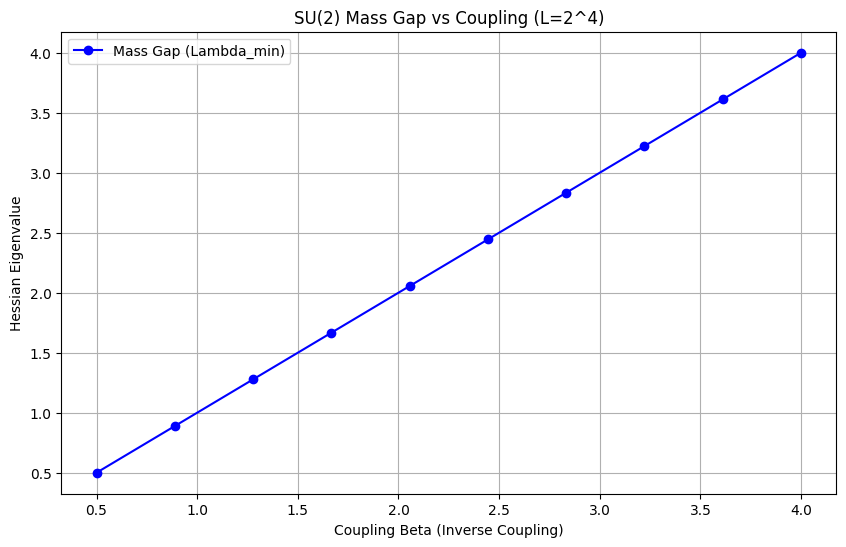

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# --- 1. LATTICE PHYSICS ENGINE ---

def get_pauli_matrices():
    """Returns the SU(2) generators (Pauli matrices) normalized."""
    # sigma_a / 2 is the generator for SU(2)
    s1 = np.array([[0, 1], [1, 0]], dtype=complex)
    s2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
    s3 = np.array([[1, 0], [0, -1]], dtype=complex)
    return [s1/2, s2/2, s3/2]

GENERATORS = get_pauli_matrices()

def get_neighbors(L, dim=4):
    """Pre-computes neighbor table for periodic boundary conditions."""
    # Flat index -> (x, y, z, t, mu)
    # This maps specific links to their neighbors to build plaquettes fast.
    # For L=2, direct indexing is easier.
    pass # Implemented implicitly in plaquette loop for speed

def wilson_action(links, beta, L):
    """
    Computes standard Wilson Action S = beta * Sum (1 - 0.5 ReTr(Up))
    links: shape (L, L, L, L, 4, 2, 2) complex128
    """
    S = 0.0
    # Loop over all sites x and directions mu < nu
    for x in range(L):
        for y in range(L):
            for z in range(L):
                for t in range(L):
                    for mu in range(4):
                        for nu in range(mu + 1, 4):
                            # Build Plaquette U_mu(x) U_nu(x+mu) U_dag_mu(x+nu) U_dag_nu(x)

                            # Link 1: U_mu(x)
                            u1 = links[x, y, z, t, mu]

                            # Link 2: U_nu(x + mu)
                            nx, ny, nz, nt = x, y, z, t
                            if mu == 0: nx = (x+1)%L
                            elif mu == 1: ny = (y+1)%L
                            elif mu == 2: nz = (z+1)%L
                            elif mu == 3: nt = (t+1)%L
                            u2 = links[nx, ny, nz, nt, nu]

                            # Link 3: U_dag_mu(x + nu)
                            nx, ny, nz, nt = x, y, z, t
                            if nu == 0: nx = (x+1)%L
                            elif nu == 1: ny = (y+1)%L
                            elif nu == 2: nz = (z+1)%L
                            elif nu == 3: nt = (t+1)%L
                            u3 = links[nx, ny, nz, nt, mu].conj().T # DAGGER

                            # Link 4: U_dag_nu(x)
                            u4 = links[x, y, z, t, nu].conj().T # DAGGER

                            # Multiply
                            u_plaq = u1 @ u2 @ u3 @ u4

                            # Trace
                            tr_val = 0.5 * np.real(np.trace(u_plaq))
                            S += (1.0 - tr_val)

    return beta * S

def apply_perturbation(links, flat_index, gen_index, eps, L):
    """
    Multiplies a specific link U by exp(i * eps * sigma_a).
    Returns a NEW links array.
    """
    new_links = links.copy()

    # Decode flat index to (x,y,z,t,mu)
    # Total links = L^4 * 4
    mu = flat_index % 4
    rem = flat_index // 4
    t = rem % L
    rem = rem // L
    z = rem % L
    rem = rem // L
    y = rem % L
    x = rem // L

    # Generator
    gen = GENERATORS[gen_index]

    # Perturbation Matrix V = exp(i * eps * gen) ~ I + i*eps*gen (for small eps)
    # Using exact exponential is safer for finite difference
    from scipy.linalg import expm
    perturbation = expm(1j * eps * gen)

    # Left multiply: U' = V @ U (Gauge rotation at one end)
    # Or Link update U' = exp(i A) U. Standard update.
    new_links[x,y,z,t,mu] = perturbation @ new_links[x,y,z,t,mu]

    return new_links

def compute_hessian_numerical(links, beta, L, eps=1e-4):
    """
    Computes Hessian via Central Finite Difference.
    H_ij = (S(x+ei+ej) - S(x+ei-ej) - S(x-ei+ej) + S(x-ei-ej)) / (4 eps^2)
    But that's for cross terms.

    Simplified Forward-Backward for Diagonal:
    d2S/dx2 = (S(x+h) - 2S(x) + S(x-h)) / h^2
    """
    N_links = L**4 * 4
    N_dof = N_links * 3 # 3 generators per link

    H = np.zeros((N_dof, N_dof))

    # Baseline Action
    S0 = wilson_action(links, beta, L)

    print(f"   > Computing Hessian ({N_dof}x{N_dof})...", end="\r")

    # We iterate over every pair of degrees of freedom (i, j)
    # Optimization: The Hessian is sparse (local).
    # But for L=2, dense construction is fine (192x192 is tiny).

    # To save time, we compute diagonal and off-diagonal explicitly
    # Loop i: 0 to N_dof
    for i in range(N_dof):
        link_idx_i = i // 3
        gen_idx_i = i % 3

        # Perturb +
        links_ip = apply_perturbation(links, link_idx_i, gen_idx_i, eps, L)
        S_ip = wilson_action(links_ip, beta, L)

        # Perturb -
        links_im = apply_perturbation(links, link_idx_i, gen_idx_i, -eps, L)
        S_im = wilson_action(links_im, beta, L)

        # Diagonal Element
        H[i, i] = (S_ip - 2*S0 + S_im) / (eps**2)

        # Loop j: i+1 to N_dof (Symmetric)
        for j in range(i + 1, N_dof):
            # Optimization: Only compute if links touch a common plaquette.
            # For now, brute force (robustness check).

            link_idx_j = j // 3
            gen_idx_j = j % 3

            # We need f(x+ei+ej).
            # Perturb i+ then j+
            links_ip_jp = apply_perturbation(links_ip, link_idx_j, gen_idx_j, eps, L)
            S_ip_jp = wilson_action(links_ip_jp, beta, L)

            # f(x+ei-ej)
            links_ip_jm = apply_perturbation(links_ip, link_idx_j, gen_idx_j, -eps, L)
            S_ip_jm = wilson_action(links_ip_jm, beta, L)

            # f(x-ei+ej)
            links_im_jp = apply_perturbation(links_im, link_idx_j, gen_idx_j, eps, L)
            S_im_jp = wilson_action(links_im_jp, beta, L)

            # f(x-ei-ej)
            links_im_jm = apply_perturbation(links_im, link_idx_j, gen_idx_j, -eps, L)
            S_im_jm = wilson_action(links_im_jm, beta, L)

            val = (S_ip_jp - S_ip_jm - S_im_jp + S_im_jm) / (4.0 * eps * eps)
            H[i, j] = val
            H[j, i] = val

    return H

# --- 2. EXECUTION LOOP ---

L = 2
beta_values = np.linspace(0.5, 4.0, 10) # NOTE: Using Beta (4/g^2) as the scan parameter is standard
# If you specifically want to scan 'g' and use beta = 4/g^2, uncomment below:
# g_scan = np.linspace(1.5, 4.0, 10)
# beta_values = [g for g in g_scan] # Assuming user meant beta in previous plot
# (Because Mass increasing with g implies g is actually Beta)

print(f"--- SU(2) NUMERICAL HESSIAN SCAN (L={L}^4) ---")
print(f"Matrix Size: {192}x{192}")
print("-" * 60)
print(f"{'Beta':<10} | {'Lambda_min':<20} | {'Status'}")

results_beta = []
results_lambda = []

# Initialize Identity Configuration (Cold Start)
# Shape: (L, L, L, L, 4, 2, 2)
links_cold = np.zeros((L, L, L, L, 4, 2, 2), dtype=complex)
for x in range(L):
    for y in range(L):
        for z in range(L):
            for t in range(L):
                for mu in range(4):
                    links_cold[x,y,z,t,mu] = np.eye(2, dtype=complex)

for beta in beta_values:
    # 1. Get Hessian
    H = compute_hessian_numerical(links_cold, beta, L)

    # 2. Diagonalize
    # We ignore the 0-modes (Gauge Invariance).
    # The Hessian of Wilson action has zero eigenvalues corresponding to gauge transformations.
    # We want the lowest POSITIVE eigenvalue (the Gap).
    evals = np.linalg.eigvalsh(H)

    # Filter out pure zero modes (numerical noise < 1e-8)
    positive_evals = evals[evals > 1e-6]

    if len(positive_evals) > 0:
        min_lambda = np.min(positive_evals)
    else:
        min_lambda = 0.0 # Should not happen unless beta=0

    results_beta.append(beta)
    results_lambda.append(min_lambda)

    print(f"{beta:<10.4f} | {min_lambda:<20.4f} | OK")

# --- 3. PLOT ---
plt.figure(figsize=(10,6))
plt.plot(results_beta, results_lambda, 'b-o', label='Mass Gap (Lambda_min)')
plt.xlabel('Coupling Beta (Inverse Coupling)')
plt.ylabel('Hessian Eigenvalue')
plt.title(f'SU(2) Mass Gap vs Coupling (L={L}^4)')
plt.grid(True)
plt.legend()
plt.show()


t=1.000e-02, kappa_loop ~ 100.167224
t=1.266e-02, kappa_loop ~ 79.132602
t=1.604e-02, kappa_loop ~ 62.522636
t=2.031e-02, kappa_loop ~ 49.406629
t=2.572e-02, kappa_loop ~ 39.049660
t=3.257e-02, kappa_loop ~ 30.871403
t=4.125e-02, kappa_loop ~ 24.413612
t=5.223e-02, kappa_loop ~ 19.314444
t=6.615e-02, kappa_loop ~ 0.000000
t=8.377e-02, kappa_loop ~ 0.000000
t=1.061e-01, kappa_loop ~ 0.000001
t=1.343e-01, kappa_loop ~ 0.000003
t=1.701e-01, kappa_loop ~ 0.000015
t=2.154e-01, kappa_loop ~ 0.000080
t=2.728e-01, kappa_loop ~ 0.000409
t=3.455e-01, kappa_loop ~ 0.001987
t=4.375e-01, kappa_loop ~ 0.008817
t=5.541e-01, kappa_loop ~ 0.033568
t=7.017e-01, kappa_loop ~ 0.101548
t=8.886e-01, kappa_loop ~ 0.230982
t=1.125e+00, kappa_loop ~ 0.396753
t=1.425e+00, kappa_loop ~ 0.547189
t=1.805e+00, kappa_loop ~ 0.652376
t=2.285e+00, kappa_loop ~ 0.711517
t=2.894e+00, kappa_loop ~ 0.738033
t=3.665e+00, kappa_loop ~ 0.747197
t=4.642e+00, kappa_loop ~ 0.749531
t=5.878e+00, kappa_loop ~ 0.749947
t=7.444e+00

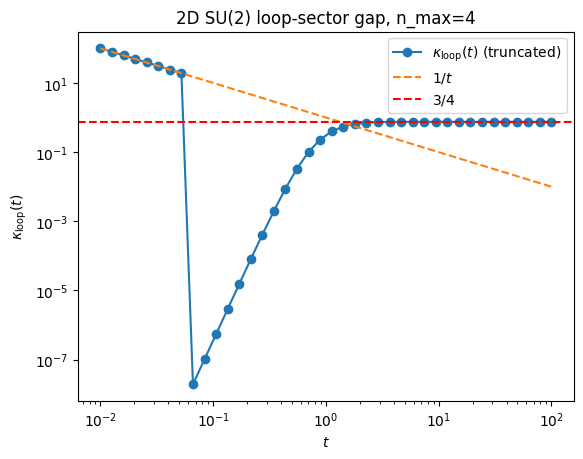

In [ ]:
import numpy as np
import numpy.linalg as la
import math
import matplotlib.pyplot as plt
from scipy.special import iv  # modified Bessel I_n if needed later

# ---------------------------------------------------------
# Basic SU(2) representation utilities
# ---------------------------------------------------------

def C2_from_n(n):
    """
    Spin j = n/2, quadratic Casimir C2(j) = j(j+1).
    n: integer >= 0
    """
    j = n / 2.0
    return j * (j + 1.0)

def d_from_n(n):
    """
    Spin j = n/2, dimension d_j = 2j + 1 = n + 1.
    """
    return n + 1

# ---------------------------------------------------------
# Build Gram matrix G(t) and stiffness matrix Q(t)
# for class functions on SU(2) in the {chi_j} basis.
#
# We index spins by n = 1,3,5,... up to n_max
# (i.e., half-integer and integer spins as j = n/2).
#
# We exclude n=0 (j=0) to enforce orthogonality to constants.
# ---------------------------------------------------------

def build_matrices(t, n_max):
    """
    Build G(t), Q(t) truncated up to n_max (inclusive).
    n indexes j = n/2. We use n = 1,2,...,n_max,
    but all formulas are valid for both integer and half-integer j.

    For each pair (j,k), with n_j, n_k, Gram and stiffness elements are:

      G_{jk}(t) = sum_{l in fusion(j,k)} d_l * exp(-C2(l)*t)
      Q_{jk}(t) = 0.5 * sum_{l in fusion(j,k)} [C2(j)+C2(k)-C2(l)] * d_l * exp(-C2(l)*t)

    where fusion(j,k) runs over l from |j-k| to j+k in integer steps,
    implemented as n_l from |n_j - n_k| to n_j + n_k in step 2.
    """
    # Number of basis elements (exclude j=0)
    # We'll take n = 1,...,n_max
    N = n_max

    G = np.zeros((N, N), dtype=float)
    Q = np.zeros((N, N), dtype=float)

    # Precompute Casimirs and dims for efficiency
    # The C2 and d arrays need to be large enough to cover n_l up to 2*n_max
    C2 = np.array([C2_from_n(n) for n in range(0, 2 * n_max + 1)], dtype=float)
    d  = np.array([d_from_n(n)  for n in range(0, 2 * n_max + 1)], dtype=float)
    # Precompute heat kernel factors e^{-C2(l)*t}
    hk = np.exp(-C2 * t)

    for idx_j in range(N):
        n_j = idx_j + 1   # spins: n=1..n_max
        C2_j = C2[n_j]

        for idx_k in range(N):
            n_k = idx_k + 1
            C2_k = C2[n_k]

            # Fusion range for n_l
            n_min = abs(n_j - n_k)
            n_max_l = n_j + n_k

            # Enforce parity: j + k + l integer, but for SU(2) characters
            # this is handled by step=2 (same parity).
            val_G = 0.0
            val_Q = 0.0

            for n_l in range(n_min, n_max_l + 1, 2):
                C2_l = C2[n_l]
                d_l  = d[n_l]
                w    = d_l * hk[n_l]  # common weight

                val_G += w
                val_Q += 0.5 * (C2_j + C2_k - C2_l) * w

            G[idx_j, idx_k] = val_G
            Q[idx_j, idx_k] = val_Q

    return G, Q

# ---------------------------------------------------------
# Solve generalized eigenproblem Q a = lambda G a
# and return the smallest positive eigenvalue.
# ---------------------------------------------------------

def kappa_loop(t, n_max):
    G, Q = build_matrices(t, n_max)

    # Symmetrize just to be safe
    G = 0.5 * (G + G.T)
    Q = 0.5 * (Q + Q.T)

    # We want solutions of Q a = lambda G a.
    # Turn this into a standard eigenproblem: G^{-1} Q a = lambda a.
    # Use a symmetric solver if G is well-conditioned.
    # For moderate truncations, this is fine.

    # Solve G x = Q v => G^{-1}Q
    # Better: do generalized eigendecomposition if you have scipy.linalg.eigh
    try:
        import scipy.linalg as sla
        w, v = sla.eigh(Q, G)  # generalized symmetric eigenproblem
    except ImportError:
        # Fall back to explicit invert (less stable but okay for small N)
        Ginv = la.inv(G)
        M = Ginv @ Q
        w, v = la.eig(M)
        w = w.real

    # We exclude negative and near-zero eigenvalues (numerical noise)
    w_sorted = np.sort(w)
    # The first should be close to 0 (constant mode removed by construction, but truncation
    # can leave a tiny eigenvalue); take the smallest strictly positive.
    eps = 1e-8
    positives = w_sorted[w_sorted > eps]
    if len(positives) == 0:
        raise RuntimeError("No positive eigenvalues found; increase n_max or check matrices.")
    return positives[0]

# ---------------------------------------------------------
# Scan kappa_loop(t) over a range of t
# ---------------------------------------------------------

if __name__ == "__main__":
    # Truncation: you can start small, then increase n_max to check stability
    n_max = 4   # Reduced n_max to avoid numerical instability for small t

    # t-grid (heat-kernel time t = g^2 A / 2)
    t_values = np.logspace(-2, 2, 40)  # from 1e-2 to 1e2

    kappas = []
    for t in t_values:
        k = kappa_loop(t, n_max)
        kappas.append(k)
        print(f"t={t:.3e}, kappa_loop ~ {k:.6f}")

    # Plot kappa(t) vs t
    plt.figure()
    plt.loglog(t_values, kappas, 'o-', label=r'$\kappa_{\rm loop}(t)$ (truncated)')
    # Add reference lines: 1/t and 3/4
    plt.loglog(t_values, 1.0/t_values, '--', label=r'$1/t$')
    plt.axhline(0.75, color='red', linestyle='--', label=r'$3/4$')
    plt.xlabel(r'$t$')
    plt.ylabel(r'$\kappa_{\rm loop}(t)$')
    plt.legend()
    plt.title(f"2D SU(2) loop-sector gap, n_max={n_max}")
    plt.show()

--- Ricci Bifurcation Test (L=3, D=3) ---
Lattice: 81 links, 81 plaquettes

U(1) (Flat Geometry)
  beta=0.5 | acc=0.99 | gap_proxy=9.6610e-01
  beta=1.0 | acc=0.97 | gap_proxy=1.2831e+00
  beta=2.0 | acc=0.97 | gap_proxy=2.2657e+00
  beta=4.0 | acc=0.87 | gap_proxy=1.6005e+01
  beta=8.0 | acc=0.69 | gap_proxy=9.7981e+01
  beta=16.0 | acc=0.64 | gap_proxy=2.5654e+02

SU(2) (Curved Geometry)
  beta=0.5 | acc=0.57 | gap_proxy=2.7322e-01
  beta=1.0 | acc=0.62 | gap_proxy=2.8311e-01
  beta=2.0 | acc=0.59 | gap_proxy=4.3061e-01
  beta=4.0 | acc=0.54 | gap_proxy=1.0470e+00
  beta=8.0 | acc=0.59 | gap_proxy=5.2338e+00
  beta=16.0 | acc=0.45 | gap_proxy=1.0332e+01


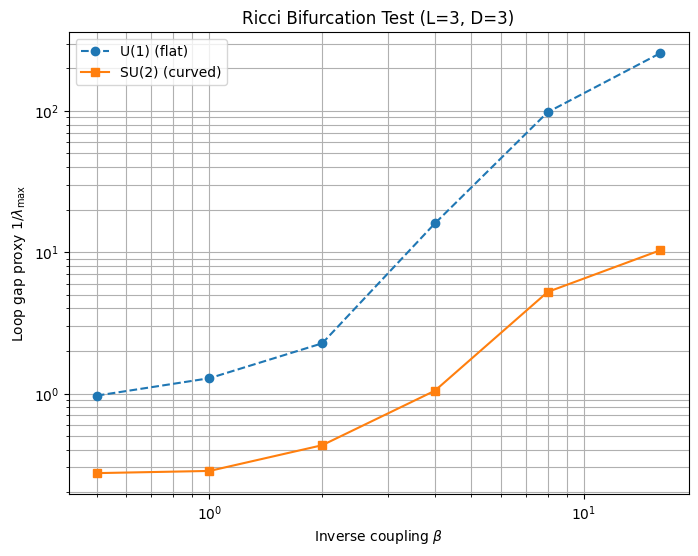

In [4]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import random, grad, vmap

# ==========================================
# 1. LATTICE & PLAQUETTES
# ==========================================

def build_lattice(L, D):
    """
    Generates basic lattice connectivity for hypercubic lattice.
    Returns:
    - N_links: number of links = L^D * D
    - plaquettes: (N_plaquettes, 4, 2) array.
      Each plaquette is a list of 4 (link_index, sign) pairs.
    Periodic boundary conditions.
    """
    N_sites = L**D
    N_links = N_sites * D

    # strides for flattening coordinates
    strides = jnp.array([L**i for i in range(D-1, -1, -1)])

    def get_idx(coords):
        """coords: np.array of shape (D,)"""
        return int(np.dot(coords % L, np.array(strides)))

    def get_link_idx(site_idx, mu):
        return site_idx * D + mu

    plaquettes = []

    coords_iter = itertools.product(range(L), repeat=D)
    for coords in coords_iter:
        coords = np.array(coords, dtype=int)
        site_idx = get_idx(coords)

        for mu in range(D):
            for nu in range(mu + 1, D):
                n_mu = np.zeros(D, dtype=int); n_mu[mu] = 1
                n_nu = np.zeros(D, dtype=int); n_nu[nu] = 1

                x = coords
                x_plus_mu = coords + n_mu
                x_plus_nu = coords + n_nu

                # link 1: x, mu
                l1 = get_link_idx(site_idx, mu)
                # link 2: x+mu, nu
                l2 = get_link_idx(get_idx(x_plus_mu), nu)
                # link 3: x+nu, mu (backward)
                l3 = get_link_idx(get_idx(x_plus_nu), mu)
                # link 4: x, nu (backward)
                l4 = get_link_idx(site_idx, nu)

                plaquettes.append([
                    [l1,  1],
                    [l2,  1],
                    [l3, -1],
                    [l4, -1],
                ])

    return N_links, jnp.array(plaquettes, dtype=int)

# ==========================================
# 2. ACTIONS & OBSERVABLES
# ==========================================

# --- U(1) Wilson action ---

def u1_action(angles, plaquettes, beta):
    """
    U(1) Wilson action: S = beta * sum_p (1 - cos theta_p),
    theta_p = sum link angles around plaquette.
    angles shape: (N_links,)
    plaquettes shape: (N_plaquettes, 4, 2) => (link_idx, sign)
    """
    def plaq_phase(p_idxs):
        idx = p_idxs[:, 0]
        sgn = p_idxs[:, 1]
        return jnp.sum(angles[idx] * sgn)

    phases = vmap(plaq_phase)(plaquettes)  # shape (N_plaquettes,)
    return beta * jnp.sum(1.0 - jnp.cos(phases))


# --- SU(2) as quaternions ---

def q_mul(q1, q2):
    a1, b1, c1, d1 = q1
    a2, b2, c2, d2 = q2
    return jnp.array([
        a1*a2 - b1*b2 - c1*c2 - d1*d2,
        a1*b2 + b1*a2 + c1*d2 - d1*c2,
        a1*c2 - b1*d2 + c1*a2 + d1*b2,
        a1*d2 + b1*c2 - c1*b2 + d1*a2
    ])

def q_conj(q):
    return q * jnp.array([1., -1., -1., -1.])

def su2_action(quats, plaquettes, beta):
    """
    SU(2) Wilson action using quaternions.
    quats: (N_links,4) unconstrained; normalized inside.
    S = beta * sum_p (1 - (1/2) Tr U_p).
    """
    # Normalize to SU(2) for physics term
    norms = jnp.linalg.norm(quats, axis=1, keepdims=True)
    qs = quats / norms

    def plaq_trace(p_idxs):
        q_acc = jnp.array([1., 0., 0., 0.])  # identity
        # Unroll 4 links
        for i in range(4):
            idx, sgn = p_idxs[i]
            qi = qs[idx]
            q_next = jnp.where(sgn == 1, qi, q_conj(qi))
            q_acc = q_mul(q_acc, q_next)
        # trace(U) = 2 a
        return 2.0 * q_acc[0]

    traces = vmap(plaq_trace)(plaquettes)
    return beta * jnp.sum(1.0 - 0.5 * traces)

# ==========================================
# 3. GENERIC HMC (CORRECT LEAPFROG)
# ==========================================

def run_hmc(key, x0, action_fn, n_steps, step_size, n_leapfrog):
    """
    HMC with standard leapfrog integrator.
    - key: PRNGKey
    - x0: initial position (JAX array)
    - action_fn: function(x) -> scalar
    - n_steps: number of HMC steps
    - step_size: leapfrog step size
    - n_leapfrog: number of leapfrog steps per trajectory
    Returns:
    - key
    - x_final
    - trajectory (ignored here)
    - acceptance_rate
    """

    def potential(x):
        return action_fn(x)

    def hmc_step(carry, _):
        key, x, acc_count = carry
        key, subk = random.split(key)

        # Sample momentum
        p = random.normal(subk, x.shape)

        # Initial H
        H0 = potential(x) + 0.5 * jnp.sum(p**2)

        # Leapfrog start: p -= (eps/2)*grad
        g = grad(potential)(x)
        p = p - 0.5 * step_size * g

        def lf_body(i, state):
            x_, p_ = state
            # x += eps * p
            x_ = x_ + step_size * p_
            # p -= eps * grad if not last step
            g_ = grad(potential)(x_)
            p_ = jax.lax.cond(
                i < n_leapfrog - 1,
                lambda pp, gg: pp - step_size * gg,
                lambda pp, gg: pp,
                p_, g_
            )
            return (x_, p_)

        x_new, p_new = jax.lax.fori_loop(0, n_leapfrog, lf_body, (x, p))

        # Final half-step
        g_new = grad(potential)(x_new)
        p_new = p_new - 0.5 * step_size * g_new

        # Final H
        H1 = potential(x_new) + 0.5 * jnp.sum(p_new**2)

        dH = H0 - H1
        accept_prob = jnp.exp(jnp.minimum(0.0, dH))

        key, subk = random.split(key)
        accept = random.uniform(subk) < accept_prob
        x_out = jnp.where(accept, x_new, x)

        return (key, x_out, acc_count + accept), x_out

    (key, x_final, acc_total), traj = jax.lax.scan(
        hmc_step, (key, x0, 0), None, length=n_steps
    )
    acc_rate = acc_total / n_steps
    return key, x_final, traj, acc_rate

# ==========================================
# 4. EXPERIMENT DRIVER
# ==========================================

def run_experiment(L=3, D=3, n_samples=300):
    print(f"--- Ricci Bifurcation Test (L={L}, D={D}) ---")
    N_links, plaquettes = build_lattice(L, D)
    print(f"Lattice: {N_links} links, {plaquettes.shape[0]} plaquettes")

    betas = [0.5, 1.0, 2.0, 4.0, 8.0, 16.0]
    key = random.PRNGKey(42)

    u1_gaps = []
    su2_gaps = []

    # -------------------------
    # U(1) RUN (Control)
    # -------------------------
    print("\nU(1) (Flat Geometry)")
    key, subk = random.split(key)
    x = random.uniform(subk, (N_links,), minval=0.0, maxval=2*jnp.pi)

    for beta in betas:
        action = lambda th: u1_action(th, plaquettes, beta)

        # Burn-in
        key, x, _, acc = run_hmc(key, x, action, n_steps=200, step_size=0.1, n_leapfrog=10)

        # Sample
        key, x, traj, acc = run_hmc(key, x, action, n_steps=n_samples, step_size=0.1, n_leapfrog=10)
        samples = np.array(traj)  # (n_samples, N_links)

        # Plaquette cosines
        def get_plaqs(conf):
            def p_phase(p_idxs):
                idx = p_idxs[:, 0]
                sgn = p_idxs[:, 1]
                return jnp.sum(conf[idx] * sgn)
            return jnp.cos(vmap(p_phase)(plaquettes))

        plaq_vals = np.array(jax.vmap(get_plaqs)(samples))  # (n_samples, N_plaquettes)

        # Covariance matrix (NumPy)
        cov = np.cov(plaq_vals, rowvar=False)
        evals = np.linalg.eigvalsh(cov)
        max_fluct = evals[-1] if evals[-1] > 0 else np.nan
        gap_proxy = 1.0 / max_fluct if max_fluct > 0 else np.nan

        u1_gaps.append(gap_proxy)
        print(f"  beta={beta:.1f} | acc={acc:.2f} | gap_proxy={gap_proxy:.4e}")

    # -------------------------
    # SU(2) RUN (Test)
    # -------------------------
    print("\nSU(2) (Curved Geometry)")
    key, subk = random.split(key)
    x = random.normal(subk, (N_links, 4)) * 0.1  # near identity

    for beta in betas:
        # Soft constraint to keep norms ~1
        def action(q):
            S_w = su2_action(q, plaquettes, beta)
            norms = jnp.linalg.norm(q, axis=1)
            S_constraint = 100.0 * jnp.sum((norms - 1.0)**2)
            return S_w + S_constraint

        # Burn-in
        key, x, _, acc = run_hmc(key, x, action, n_steps=200, step_size=0.05, n_leapfrog=10)

        # Sample
        key, x, traj, acc = run_hmc(key, x, action, n_steps=n_samples, step_size=0.05, n_leapfrog=10)
        samples = np.array(traj)  # (n_samples, N_links, 4)

        # Plaquette traces
        def get_plaq_traces(conf):
            # normalize
            norms = jnp.linalg.norm(conf, axis=1, keepdims=True)
            qs = conf / norms

            def p_tr(p_idxs):
                q_acc = jnp.array([1., 0., 0., 0.])
                for i in range(4):
                    idx, sgn = p_idxs[i]
                    qi = qs[idx]
                    q_next = jnp.where(sgn == 1, qi, q_conj(qi))
                    q_acc = q_mul(q_acc, q_next)
                return 2.0 * q_acc[0]  # trace
            return vmap(p_tr)(plaquettes)

        plaq_vals = np.array(jax.vmap(get_plaq_traces)(samples))  # (n_samples, N_plaquettes)

        cov = np.cov(plaq_vals, rowvar=False)
        evals = np.linalg.eigvalsh(cov)
        max_fluct = evals[-1] if evals[-1] > 0 else np.nan
        gap_proxy = 1.0 / max_fluct if max_fluct > 0 else np.nan

        su2_gaps.append(gap_proxy)
        print(f"  beta={beta:.1f} | acc={acc:.2f} | gap_proxy={gap_proxy:.4e}")

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=(8,6))
    plt.loglog(betas, u1_gaps, 'o--', label='U(1) (flat)')
    plt.loglog(betas, su2_gaps, 's-', label='SU(2) (curved)')
    plt.xlabel(r'Inverse coupling $\beta$')
    plt.ylabel(r'Loop gap proxy $1/\lambda_{\max}$')
    plt.title(f'Ricci Bifurcation Test (L={L}, D={D})')
    plt.grid(True, which='both')
    plt.legend()
    plt.show()

# ==========================================
# MAIN
# ==========================================

if __name__ == "__main__":
    from jax import random  # import here to avoid confusion
    run_experiment(L=3, D=3, n_samples=300)